In [1]:
from ortools.linear_solver import *
import networkx as nx
import matplotlib.pyplot as plt



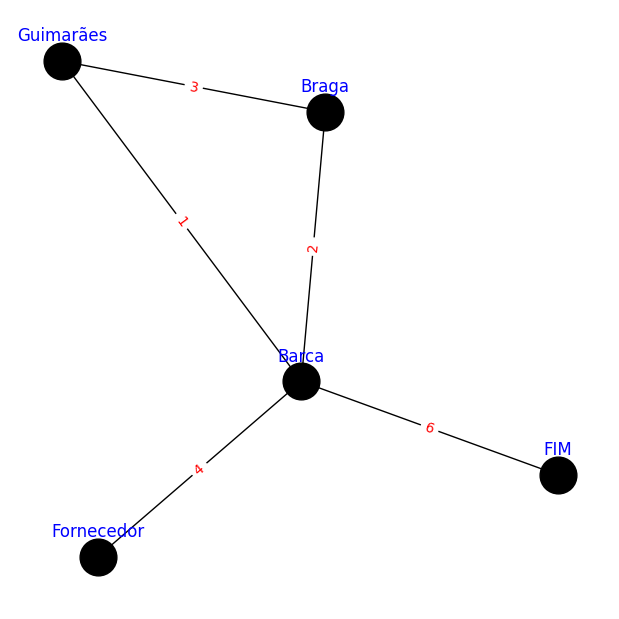

In [ ]:

# Função para criar o grafo
def criaGrafo(R):
    Grafo = nx.Graph()
    for node in R:
        for t in R[node]:
            Grafo.add_edge(node, t[0], weight=t[1])
    return Grafo

# Ruas e Locais
R = {
    "Braga": [("Guimarães", 3), ("Barca", 2)],
    "Guimarães": [("Barca", 1)],
    "Barca": [("Fornecedor",4),("FIM",6)]
}

# Fornecedores
F={
    "Fornecedor":[(50,5)]
}

# Sinks
O={
    "Fim":{
        1:3,
        2:5,
        5:4
        }    
}

# Cenas para o grafo ficar bem dessenhado
Grafo = criaGrafo(R)
pos = nx.spring_layout(Grafo)

plt.figure(figsize=(6, 6))
nx.draw(Grafo, pos, node_color="black", node_size=700)


label_pos = {k: (v[0], v[1] + 0.1) for k, v in pos.items()}

nx.draw_networkx_labels(Grafo, label_pos, font_size=12, font_color="blue")

edge_labels = nx.get_edge_attributes(Grafo, 'weight')
nx.draw_networkx_edge_labels(Grafo, pos, edge_labels=edge_labels, font_color="red")

plt.show()

# Solver
def res(Grafo, F, O, R):
    solver = pywraplp.Solver.CreateSolver('SCIP')

    Grafo=criaGrafo(R)
    
    # variaveis
    p={}
    for tipo in [1,2,5]:
        p[tipo]=solver.IntVar(0,solver.infinity(),f'p_{tipo}')
    # f={}
    # for e in Grafo.edges:
    #     f[e]= solver.Intvar(0,solver.infinity(), f"f_{e[0]}_{e[1]}")
    #     solver.Add(f[e]<=Grafo.edges[e]["weight"])
    
    v=solver.IntVar(0,F["Fornecedor"][1],'veiculos')

    f={}
    for(u,w) in Grafo.edges():
        f[(u,w)]=solver.IntVar(0,Grafo[u][w]['cap'],f'f_{u}_{w}')
        f[(w,u)]=solver.IntVar(0,Grafo[u][w]['cap'],f'f_{w}_{u}')
        
    #restrições
    